In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)

df['Target_Price'] = california.target

df = df[df['Target_Price']<5.0]


print(df.info())

print("--- PRIME 5 RIGHE ---")
print(df.head())

print("\n--- CORRELAZIONE CON IL PREZZO ---")
print(df.corr()['Target_Price'].sort_values(ascending=False))


<class 'pandas.DataFrame'>
Index: 19648 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MedInc        19648 non-null  float64
 1   HouseAge      19648 non-null  float64
 2   AveRooms      19648 non-null  float64
 3   AveBedrms     19648 non-null  float64
 4   Population    19648 non-null  float64
 5   AveOccup      19648 non-null  float64
 6   Latitude      19648 non-null  float64
 7   Longitude     19648 non-null  float64
 8   Target_Price  19648 non-null  float64
dtypes: float64(9)
memory usage: 1.5 MB
None
--- PRIME 5 RIGHE ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945  

In [3]:
from sklearn.model_selection import train_test_split

features = df[['MedInc', 'AveRooms', 'HouseAge', 'Population', 'AveOccup', 'Longitude', 'AveBedrms', 'Latitude']]

X_train, X_test, y_train, y_test = train_test_split(features, df['Target_Price'], test_size=0.3, random_state=42)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        # numero di alberi, campiona un intero tra 100 e 600

        'max_depth':        trial.suggest_int('max_depth', 5, 40),
        # profondità massima degli alberi, campiona un intero tra 5 e 40
        # range continuo → evita di saltare valori ottimali intermedi

        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        # feature considerate per ogni split, categorico → sceglie tra valori fissi
        # sqrt=radice(n_feature), log2=log2(n_feature), 0.5=metà delle feature

        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        # sample minimi per foglia, alzarlo regolarizza e riduce overfitting

        'bootstrap':        trial.suggest_categorical('bootstrap', [True, False]),
        # True = bagging (campione con rimpiazzo), False = tutti i sample per ogni albero
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best CV R²:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

# modello finale con i best params
final_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)
print(f"Test R²: {final_model.score(X_test, y_test):.4f}")

Best trial: 46. Best value: 0.791876: 100%|██████████| 50/50 [04:16<00:00,  5.13s/it]


Best CV R²:  0.7919
Best params: {'n_estimators': 556, 'max_depth': 21, 'max_features': 'log2', 'min_samples_leaf': 1, 'bootstrap': False}
Test R²: 0.7897


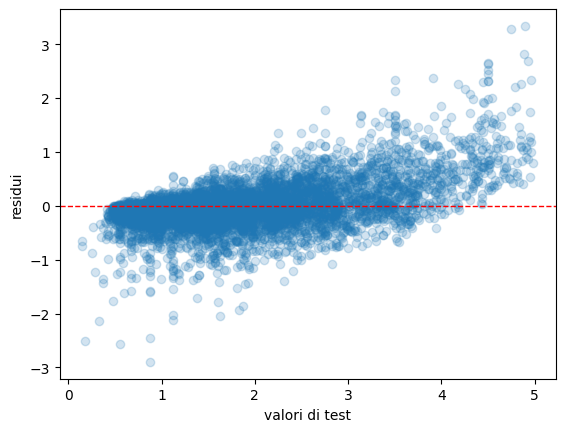

<Figure size 640x480 with 0 Axes>

In [ ]:
residuals = y_test - final_model.predict(X_test)

import matplotlib.pyplot as plt

plt.scatter(y_test, residuals, alpha=0.2)
plt.xlabel('valori di test')
plt.ylabel('residui')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()
plt.clf()

In [ ]:
final_model = RandomForestRegressor(**search.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

print(final_model.score(X_test, y_test))

0.7890993292088586


In [ ]:
print(final_model.predict(X_test[10:20]))
print(y_test[10:20])

[2.10369277 2.51637775 2.08275889 1.2630126  0.63832572 2.1539811
 0.63021871 3.01468894 2.70949456 2.41965224]
8454     2.370
15934    2.713
3703     1.989
9768     0.766
19756    0.649
7106     2.010
19894    0.456
1539     3.127
6784     3.814
15857    2.083
Name: Target_Price, dtype: float64
